# Kernel PCA

---

## Kenapa Kernel PCA?

PCA cuma bisa tangkap hubungan **linear**. Kalau data punya pola non-linear (misal: dua class bentuk bulan sabit), PCA gagal misahin mereka.

Kernel PCA solve masalah ini pakai **kernel trick** — hitung similarity di high-dimensional space tanpa beneran transformasi ke sana. Secara implisit, data "diangkat" ke dimensi lebih tinggi di mana polanya jadi linear, lalu PCA dilakukan di sana.

### Jenis Kernel

| Kernel | Keterangan |
|--------|------------|
| **RBF** | Default, paling umum. Parameter: `gamma` |
| **Polynomial** | Tangkap interaksi antar fitur. Parameter: `degree`, `gamma` |
| **Sigmoid** | Jarang dipakai, butuh tuning yang teliti |

### Parameter Gamma (RBF)

- Gamma kecil: smooth, setiap titik "lihat" tetangga yang jauh juga
- Gamma besar: detail, cuma lihat tetangga dekat
- Terlalu besar: overfit, titik-titik jadi terisolasi

### PCA vs Kernel PCA

| | PCA | Kernel PCA |
|---|---|---|
| Hubungan | Linear | Non-linear |
| Parameter | `n_components` | `kernel`, `gamma`, `n_components` |
| Explained variance | Ada | Tidak ada (implicit space) |
| Speed | Cepat | Lebih lambat |

---

## Worked Example: Kernel Matrix

Sebelum pakai sklearn, kita lihat dulu apa yang terjadi di balik Kernel PCA.

4 titik di 2D:

| Titik | $x_1$ | $x_2$ | Class |
|:---:|:---:|:---:|:---:|
| A | 0.0 | 0.0 | 0 |
| B | 1.0 | 0.0 | 0 |
| C | 0.5 | 0.8 | 1 |
| D | 0.5 | -0.8 | 1 |

Class 0 (A, B) di tengah, class 1 (C, D) di atas-bawah — tidak bisa dipisah pakai garis lurus.

### RBF Kernel Matrix (gamma=1)

$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$

Contoh: $K(A, C) = \exp(-1 \times (0.25 + 0.64)) = \exp(-0.89) \approx 0.411$

| | A | B | C | D |
|---|---|---|---|---|
| **A** | 1.000 | 0.368 | 0.411 | 0.411 |
| **B** | 0.368 | 1.000 | 0.411 | 0.411 |
| **C** | 0.411 | 0.411 | 1.000 | 0.202 |
| **D** | 0.411 | 0.411 | 0.202 | 1.000 |

Kernel PCA lakukan eigen decomposition pada matrix K ini (setelah centering), hasilnya komponen baru yang bisa misahin class. Di bawah, `sklearn.decomposition.KernelPCA` lakukan semua ini otomatis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, load_wine
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

---

## Demo: PCA vs Kernel PCA pada Make Moons

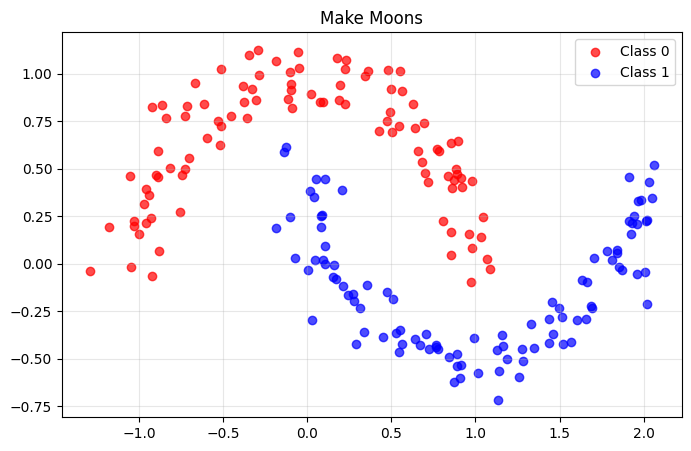

In [2]:
X, y = make_moons(n_samples=200, random_state=123, noise=0.1)

plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', alpha=0.7)
plt.title('Make Moons')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Dua class bentuk bulan sabit, saling menghadap. Tidak ada garis lurus yang bisa pisahin keduanya.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Kernel PCA
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15, random_state=123)
X_kpca = kpca.fit_transform(X_scaled)

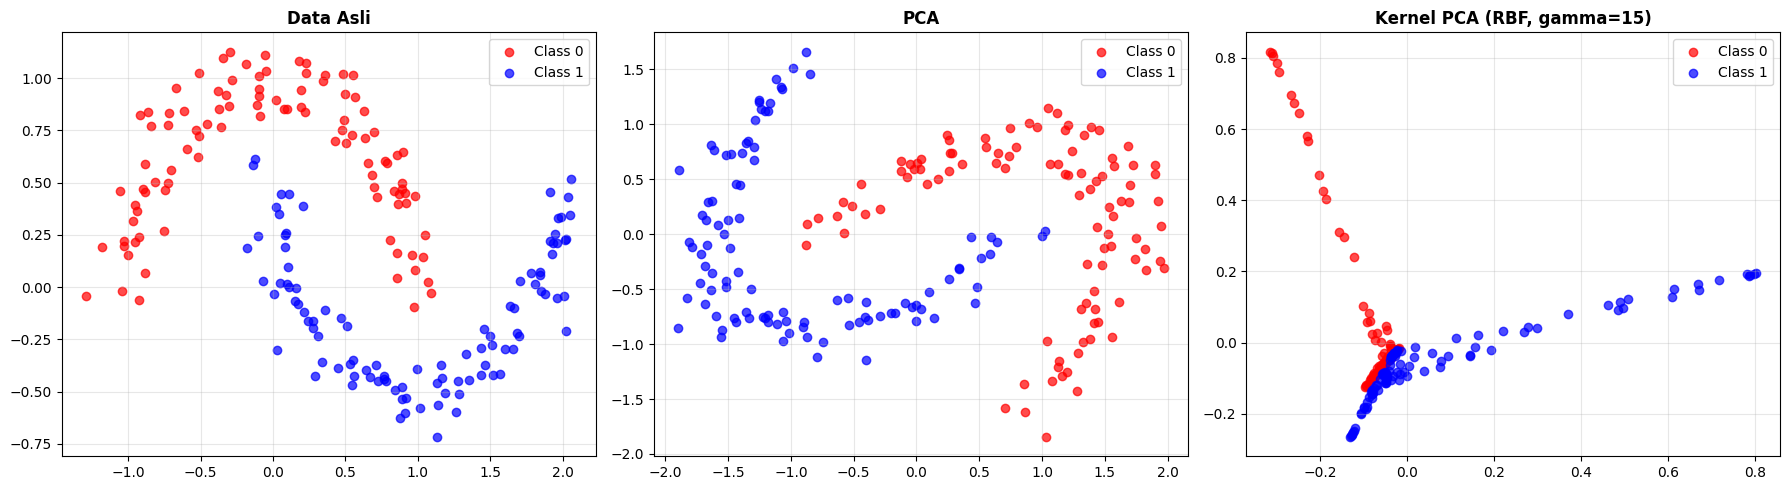

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(axes,
    [X, X_pca, X_kpca],
    ['Data Asli', 'PCA', 'Kernel PCA (RBF, gamma=15)']):
    ax.scatter(data[y == 0, 0], data[y == 0, 1], c='red', label='Class 0', alpha=0.7)
    ax.scatter(data[y == 1, 0], data[y == 1, 1], c='blue', label='Class 1', alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PCA gagal — kedua class masih overlap. Kernel PCA berhasil misahin class karena bisa tangkap pola non-linear.

---

## Efek Parameter Gamma

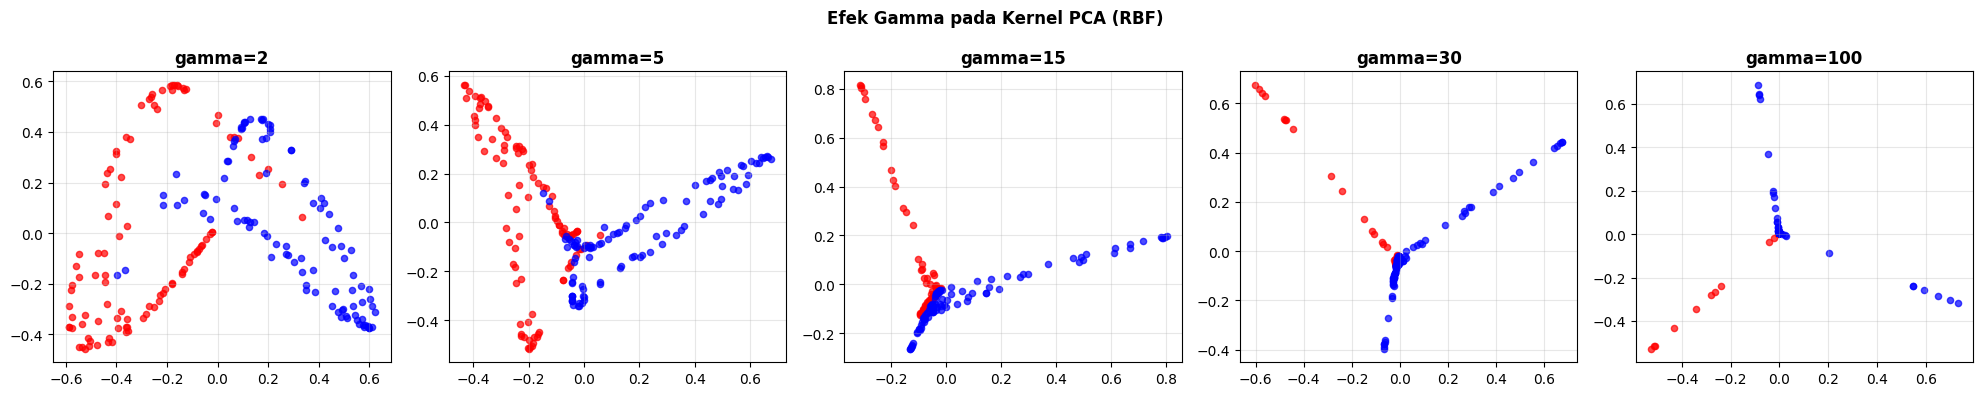

In [5]:
gammas = [2, 5, 15, 30, 100]

fig, axes = plt.subplots(1, len(gammas), figsize=(20, 4))

for i, g in enumerate(gammas):
    X_g = KernelPCA(n_components=2, kernel='rbf', gamma=g, random_state=123).fit_transform(X_scaled)
    axes[i].scatter(X_g[y == 0, 0], X_g[y == 0, 1], c='red', alpha=0.7, s=20)
    axes[i].scatter(X_g[y == 1, 0], X_g[y == 1, 1], c='blue', alpha=0.7, s=20)
    axes[i].set_title(f'gamma={g}', fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Efek Gamma pada Kernel PCA (RBF)', fontweight='bold')
plt.tight_layout()
plt.show()

- `gamma=2`: terlalu smooth, class masih overlap
- `gamma=15`: sweet spot, class terpisah jelas
- `gamma=100`: terlalu detail, titik-titik mulai terisolasi (overfit)

---

## Perbandingan Kernel

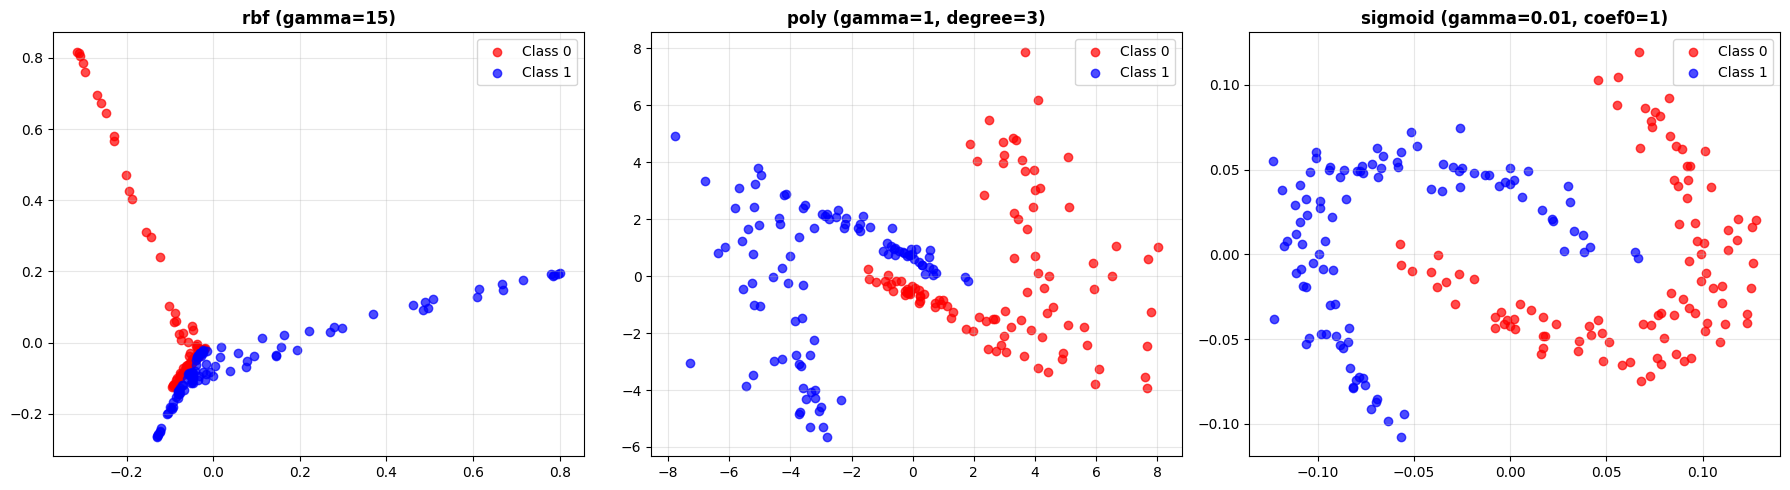

In [6]:
configs = [
    ('rbf', {'gamma': 15}),
    ('poly', {'gamma': 1, 'degree': 3}),
    ('sigmoid', {'gamma': 0.01, 'coef0': 1})
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (kernel, params) in enumerate(configs):
    X_k = KernelPCA(n_components=2, kernel=kernel, random_state=123, **params).fit_transform(X_scaled)
    axes[i].scatter(X_k[y == 0, 0], X_k[y == 0, 1], c='red', label='Class 0', alpha=0.7)
    axes[i].scatter(X_k[y == 1, 0], X_k[y == 1, 1], c='blue', label='Class 1', alpha=0.7)
    param_str = ', '.join(f'{k}={v}' for k, v in params.items())
    axes[i].set_title(f'{kernel} ({param_str})', fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RBF paling stabil buat kebanyakan kasus. Polynomial bisa jalan tapi sensitif sama `degree`. Sigmoid butuh tuning yang pas.

Rekomendasi: **mulai dari RBF**, coba kernel lain kalau RBF kurang optimal.

---

## Aplikasi pada Real Dataset: Wine

Sekarang kita coba di dataset beneran — Wine (13 fitur, 3 class).

In [7]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

pd.DataFrame(X_wine, columns=wine.feature_names).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


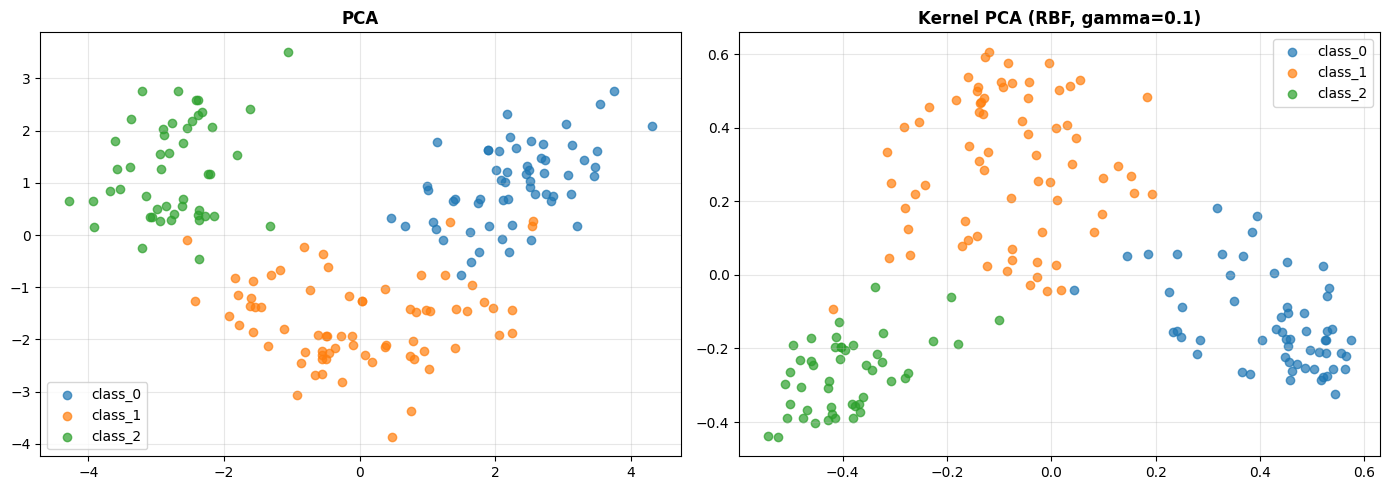

In [8]:
X_wine_scaled = StandardScaler().fit_transform(X_wine)

X_wine_pca = PCA(n_components=2).fit_transform(X_wine_scaled)
X_wine_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=123).fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in range(3):
    axes[0].scatter(X_wine_pca[y_wine == cls, 0], X_wine_pca[y_wine == cls, 1], label=wine.target_names[cls], alpha=0.7)
    axes[1].scatter(X_wine_kpca[y_wine == cls, 0], X_wine_kpca[y_wine == cls, 1], label=wine.target_names[cls], alpha=0.7)

axes[0].set_title('PCA', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title('Kernel PCA (RBF, gamma=0.1)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Downstream: Classification Accuracy

Untuk buktiin mana yang lebih berguna, kita train Logistic Regression pakai features dari masing-masing metode.

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(X_wine_scaled, y_wine, test_size=0.3, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_tr, y_tr)
acc_orig = accuracy_score(y_te, lr.predict(X_te))

pca_w = PCA(n_components=2)
lr.fit(pca_w.fit_transform(X_tr), y_tr)
acc_pca = accuracy_score(y_te, lr.predict(pca_w.transform(X_te)))

kpca_w = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=123)
lr.fit(kpca_w.fit_transform(X_tr), y_tr)
acc_kpca = accuracy_score(y_te, lr.predict(kpca_w.transform(X_te)))

pd.DataFrame({
    'Method': ['Original (13D)', 'PCA (2D)', 'Kernel PCA (2D)'],
    'Accuracy': [f'{acc_orig:.2%}', f'{acc_pca:.2%}', f'{acc_kpca:.2%}']
})

,Method,Accuracy
0,Original (13D),98.15%
1,PCA (2D),96.30%
2,Kernel PCA (2D),96.30%


In [ ]:
# Save notebook with outputs
import shutil, glob
shutil.copy('__notebook__.ipynb', 'Kernel-PCA.ipynb')
print(f'Kernel-PCA.ipynb saved to output')

---

## Kesimpulan

- PCA cuma tangkap pola **linear**. Untuk data non-linear, PCA gagal.
- Kernel PCA pakai **kernel trick** untuk tangkap pola non-linear.
- **RBF** jadi pilihan default yang paling stabil.
- **Gamma** harus di-tune: kecil = underfit, besar = overfit.
- Di real dataset, perbedaan PCA vs Kernel PCA tidak selalu signifikan — tergantung data.

---

*Referensi: Scholkopf et al. (1998). Kernel Principal Component Analysis. ICANN.*